# Lab 9 Report: 
## Final Project Codebase

## Project Title: Facial Recognition

### Group Members: Javier Guapilla Diaz & McKinley Nhi Seecof Quevedo

In [ ]:
#here's the other model: 
import torch
import torch.nn as nn
import torch.nn.functional as F

class FacialExpressionCNN(nn.Module):
    def __init__(self):
        super(FacialExpressionCNN, self).__init__()
        
        # Layer 1: Conv2D (32 filters, same padding to keep 48x48)
        # Input assumed to be 1 channel (grayscale) or 3 based on augmentation notes
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        
        # Layer 2: Conv2D (64 filters, same padding)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 3: Conv2D (64 filters, same padding)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, padding=1)
        
        # Layer 4: MaxPooling (Reduces 48x48 to 9x9 based on Table 1)
        # Note: A standard pool wouldn't jump 48->9. This implies a kernel ~5x5.
        self.pool1 = nn.MaxPool2d(kernel_size=5, stride=5) 
        
        # Layer 5: Dropout
        self.dropout1 = nn.Dropout(0.25)
        
        # Layer 6: Conv2D (128 filters, 9x9 -> 7x7)
        self.conv4 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3)
        
        # Layer 7: Conv2D (128 filters, 7x7 -> 5x5)
        self.conv5 = nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3)
        
        # Layer 8: MaxPooling (5x5 -> 1x1)
        self.pool2 = nn.MaxPool2d(kernel_size=5)
        
        # Layer 9: Dropout
        self.dropout2 = nn.Dropout(0.25)
        
        # Layer 10: Flatten (Done in forward pass)
        
        # Layer 11: Dense (500 units)
        self.fc1 = nn.Linear(128 * 1 * 1, 500)
        
        # Layer 12: Dropout
        self.dropout3 = nn.Dropout(0.5)
        
        # Layer 13: Dense (7 units for facial expressions)
        self.fc2 = nn.Linear(500, 7)

    def forward(self, x):
        # Convolutional Block 1
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.pool1(x)
        x = self.dropout1(x)
        
        # Convolutional Block 2
        x = F.relu(self.conv4(x))
        x = F.relu(self.conv5(x))
        x = self.pool2(x)
        x = self.dropout2(x)
        
        # Flattening
        x = torch.flatten(x, 1)
        
        # Dense Layers
        x = F.relu(self.fc1(x))
        x = self.dropout3(x)
        
        # Final Layer (Softmax is often handled by CrossEntropyLoss in PyTorch)
        x = self.fc2(x)
        return x

--------------------

## Imports

In [243]:
import matplotlib.pyplot as plt
import torch
import numpy as np
import torch.nn as nn
import os
from PIL import Image # For easy manipulation of images and stuff
from PIL import ImageEnhance
import random
d = torch.device('cuda')

## Prepare Data

Loading In Data

In [ ]:
# from sklearn.model_selection import train_test_split

# folders = ["train", "test"]
# emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
# path = r"C:\Users\jguap\OneDrive\Desktop\spr26\final_data\data\\"

# IMG_SIZE = (48, 48)

# all_data = []
# all_labels = []

# # loading data - no more branching, just collect everything
# for f in folders:
#     for i in range(len(emotions)):
#         e = emotions[i]
#         curr_path = os.path.join(path, f, e)
#         for filename in os.listdir(curr_path):
#             curr_image_path = os.path.join(curr_path, filename)
#             curr_image = Image.open(curr_image_path).convert("L")
#             curr_image = curr_image.resize(IMG_SIZE)

#             all_data.append(np.array(curr_image))
#             all_labels.append(i)

# # split before augmentation
# all_data = np.array(all_data)
# all_labels = np.array(all_labels)

# X_train_raw, test_data, y_train_raw, test_labels = train_test_split(
#     all_data, all_labels, test_size=0.2, stratify=all_labels, random_state=42
# )

# # augmentation only on training portion
# train_data = []
# train_labels = []

# for img, label in zip(X_train_raw, y_train_raw):
#     curr_image = Image.fromarray(img)
    
#     # original
#     train_data.append(np.array(curr_image))
#     train_labels.append(label)
#     # flip
#     train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
#     train_labels.append(label)
#     # rotation
#     angle = random.uniform(-10, 10)
#     train_data.append(np.array(curr_image.rotate(angle)))
#     train_labels.append(label)
#     # brightness
#     factor = random.uniform(0.8, 1.2)
#     train_data.append(np.array(ImageEnhance.Brightness(curr_image).enhance(factor)))
#     train_labels.append(label)

# # converting to np arrays
# train_data = np.array(train_data).reshape(-1, 1, 48, 48)
# test_data = np.array(test_data).reshape(-1, 1, 48, 48)
# train_labels = np.array(train_labels)
# test_labels = np.array(test_labels)
from sklearn.model_selection import train_test_split

folders = ["train", "test"]
emotions = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]
path = r"C:\Users\jguap\OneDrive\Desktop\spr26\final_data\data\\"
IMG_SIZE = (48, 48)

all_data = []
all_labels = []

# loading data
for f in folders:
    for i in range(len(emotions)):
        e = emotions[i]
        curr_path = os.path.join(path, f, e)
        for filename in os.listdir(curr_path):
            curr_image_path = os.path.join(curr_path, filename)
            curr_image = Image.open(curr_image_path).convert("L")
            curr_image = curr_image.resize(IMG_SIZE)
            all_data.append(np.array(curr_image))
            all_labels.append(i)

all_data = np.array(all_data)
all_labels = np.array(all_labels)

# step 1: train/test split (raw)
X_train_raw, test_data, y_train_raw, test_labels = train_test_split(
    all_data, all_labels, test_size=0.2, stratify=all_labels, random_state=42
)

# step 2: train/val split (raw, before augmentation)
X_train_raw, X_val_raw, y_train_raw, validation_labels = train_test_split(
    X_train_raw, y_train_raw, test_size=0.1, stratify=y_train_raw, random_state=2
)

# step 3: augment only training portion
train_data = []
train_labels = []

for img, label in zip(X_train_raw, y_train_raw):
    curr_image = Image.fromarray(img)
    train_data.append(np.array(curr_image))
    train_labels.append(label)
    train_data.append(np.array(curr_image.transpose(Image.FLIP_LEFT_RIGHT)))
    train_labels.append(label)
    angle = random.uniform(-10, 10)
    train_data.append(np.array(curr_image.rotate(angle)))
    train_labels.append(label)
    factor = random.uniform(0.8, 1.2)
    train_data.append(np.array(ImageEnhance.Brightness(curr_image).enhance(factor)))
    train_labels.append(label)

train_data = np.array(train_data)
train_labels = np.array(train_labels)
validation_data = X_val_raw  # no augmentation

train_total = len(train_data)

In [293]:
print(train_data.shape)
print(test_data.shape)
print(validation_data.shape)

(103352, 48, 48)
(7178, 48, 48)
(2871, 48, 48)


Reshaping

In [294]:
train_data = np.reshape(train_data, (train_total, (48*48)))# YOUR CODE HERE
test_data = np.reshape(test_data, (len(test_data), (48*48)))# YOUR CODE HERE
validation_data = np.reshape(validation_data, (len(validation_data), 48*48))

ValidationTraining $\rightarrow$ Training (90\%) & Validation (10\%)

In [ ]:
# # Take the first 1000 training features and targets as validation set

# spl = train_test_split(train_data, 
#                        train_labels, 
#                        test_size=0.1,random_state=2)
# # ^^ Splits data in following order: train feature, validation features, train targets, validation targets

# validation_data = spl[1]
# validation_labels = spl[3]

# # Take the remaining 9000 training features and targets as training set 
# train_data = spl[0]
# train_labels = spl[2]

# # Checking sizes to make sure I split correctly
# print(validation_data.shape, validation_labels.shape)
# print(train_data.shape, train_labels.shape)

(11484, 2304) (11484,)
(103352, 2304) (103352,)


Scaling

In [295]:
# Defining scaling function
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Scale the dataset according to standard scaling
train_data = scaler.fit_transform(train_data) # Fitting to and scaling training data 
validation_data = scaler.transform(validation_data)
test_data = scaler.transform(test_data)# scaling testing data

In [296]:
# Reshape train/validation/test sets to conform to PyTorch's (N, Channels, Height, Width) standard for CNNs

train_features = train_data.reshape(-1, 1, 48, 48) # Going back to 48X48 images for CNN
validation_features = validation_data.reshape(-1, 1, 48, 48) # ^^
test_features = test_data.reshape(-1,1,48,48) # ^^

# Checking the shape
print(train_features.shape)
print(validation_features.shape)
print(test_features.shape)

(103352, 1, 48, 48)
(2871, 1, 48, 48)
(7178, 1, 48, 48)


Converting to Tensors

In [297]:
# Make them into tensors
train_inputs = torch.from_numpy(train_features).float() # converting to floats
train_targets = torch.from_numpy(train_labels).long() # converting to 64-bit integer

validation_inputs = torch.from_numpy(validation_features).float().to(d) # converting to floats
validation_targets = torch.from_numpy(validation_labels).long().to(d) # converting to 64-bit integer

testing_inputs = torch.from_numpy(test_features).float().to(d) # converting to floats
testing_targets = torch.from_numpy(test_labels).long().to(d) # converting to 64-bit integer

# NOTE: Each of the tensors above used .to(d) which takes out tensors and puts them "in" my computers gpu
#       I did this to speed up computation and to actually use cuda.

## Define Model

In [298]:
# Define your CNN architecture here
import torch.nn.functional as F

class myCNNModel(torch.nn.Module):
    
    def __init__(self):
        
        super(myCNNModel, self).__init__()
        
        # Convolution followed by ReLU activation and a Maxpool
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=32,
                              kernel_size=3, stride=1, padding=1)
        self.relu1 = nn.ReLU()
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution followed by ReLU activation and a Maxpool
        self.cnn2 = nn.Conv2d(in_channels=32, out_channels=64, 
                              kernel_size=3, stride=1, padding=1)
        self.relu2 = nn.ReLU()
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # added
        self.cnn3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1)
        self.relu3 = nn.ReLU()
        self.maxpool3 = nn.MaxPool2d(kernel_size=2)
        self.bn3 = nn.BatchNorm2d(128)

        # Squishing down to fully connected chunk.
        # self.fc1 = nn.Linear(128*6*6, 256)
        # self.fc2 = nn.Linear(256, 7)
        self.fc1 = nn.Linear(128*6*6, 256)
        self.fc3 = nn.Linear(256, 64)
        self.fc2 = nn.Linear(64, 7)

        # Batch normalizations used:
        self.bn = nn.BatchNorm1d(256)
        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn4 = nn.BatchNorm1d(64)

        # dropouts
        self.dropout = nn.Dropout(0.5)
        self.dropout_conv = nn.Dropout(0.25)
    
    def forward(self, x):
        
        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.maxpool1(out)
        #out = self.dropout_conv(out) # *

        # Convolution, batch normalization, ReLU, Maxpool
        out = self.cnn2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.maxpool2(out)
        out = self.dropout_conv(out) # * 

        # ^ same as before
        out = self.cnn3(out)
        out = self.bn3(out)
        out = self.relu3(out)
        out = self.maxpool3(out)
        out = self.dropout_conv(out) # *Googled how to reduce overfitting and added this dropout

        # Flattening out our output
        out = out.view(out.size(0), -1)

        # Using a fully connected layer for the rest
        out = self.fc1(out)
        out = self.bn(out)
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc3(out)      # 256 -> 64
        out = self.bn4(out)      # BN on 64
        out = F.relu(out)

        out = self.dropout(out)
        out = self.fc2(out)
        
        return out

## Define Hyperparameters

In [299]:
# Fix the random seed so that model performance is reproducible
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader #added dataloader so that random data is batched
torch.manual_seed(55)

# Initializing model
model = myCNNModel()
model = model.to(d) # Bc I wanted to use my gpu, also "sent" model to GPU to work w/ tensors from before.

# Defining learning rate, epoch and batchsize for mini-batch gradient
learning_rate = 0.001
epochs = 60 #20 #30

## Mini-batch set up, splitting up the tensors from before
batchsize = 64
# train_batches_features = torch.split(train_inputs, batchsize)
# train_batches_targets = torch.split(train_targets, batchsize)
# batch_split_num = len(train_batches_features)
train_dataset = TensorDataset(train_inputs, train_targets)
# NOTE: num_workers is for threads, and pin_memory is for locking memory
train_loader = DataLoader(train_dataset, batch_size=batchsize, shuffle=True, pin_memory=True, num_workers=2)

# Define loss function and optimizer
loss_func = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

model # just to check the model I am using

myCNNModel(
  (cnn1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (maxpool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (maxpool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (cnn3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu3): ReLU()
  (maxpool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc1): Linear(in_features=4608, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=7, bias=True)
  (bn): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_

## Identify Tracked Values

In [300]:
# Placeholders for training loss and validation accuracy during training
train_loss_list = []
validation_loss_list = []
validation_accuracy_list = []

## Train Model

In [301]:
import tqdm #For loading bar

# Actual training of the modeL:
for epoch in tqdm.trange(epochs):
    
    model.train() # I was told in a previous class doing this is good practice.
    e_loss = 0.0 # the average loss for this epoch bc I use mini-batch
    
    # Working w the batches
    # for k in range(batch_split_num):
    for features, targets in train_loader:
        # set up:
        # using batch k to train on
        # features_k = train_batches_features[k]
        # targets_k = train_batches_targets[k]
        features_k = features.to(d)
        targets_k = targets.to(d)

        # training
        optimizer.zero_grad()
        train_batch_outputs = model(features_k)
        loss = loss_func(train_batch_outputs, targets_k)
        e_loss += loss.item()

        # moving the optimizer along
        loss.backward()
        optimizer.step()
    
    # getting the avg loss over the batches for this epoch
    # epoch_avg_loss = e_loss / batch_split_num
    epoch_avg_loss = e_loss / len(train_loader)
    train_loss_list.append(epoch_avg_loss)

    # Compute Validation Accuracy ----------------------------------------------------------------------
    model.eval() # Once again, I was told putting the model explicitly into eval mode was good practice
    with torch.no_grad(): # Telling PyTorch we aren't passing inputs to network for training purpose
        
        validation_outputs = model(validation_inputs) # Getting validation scores
        val_loss = loss_func(validation_outputs, validation_targets)
        validation_loss_list.append(val_loss.item())

        correct = (torch.argmax(validation_outputs, dim=1) == 
                   validation_targets).type(torch.FloatTensor) # converting validation scores to labels and
                                                               # counting the # of correctly labeled samples
        
        validation_accuracy_list.append(correct.mean()) # converting # of samples correct to percentage
        scheduler.step(val_loss.item())


100%|██████████| 60/60 [22:29<00:00, 22.48s/it]


## Visualize & Evaluate Model

Validation

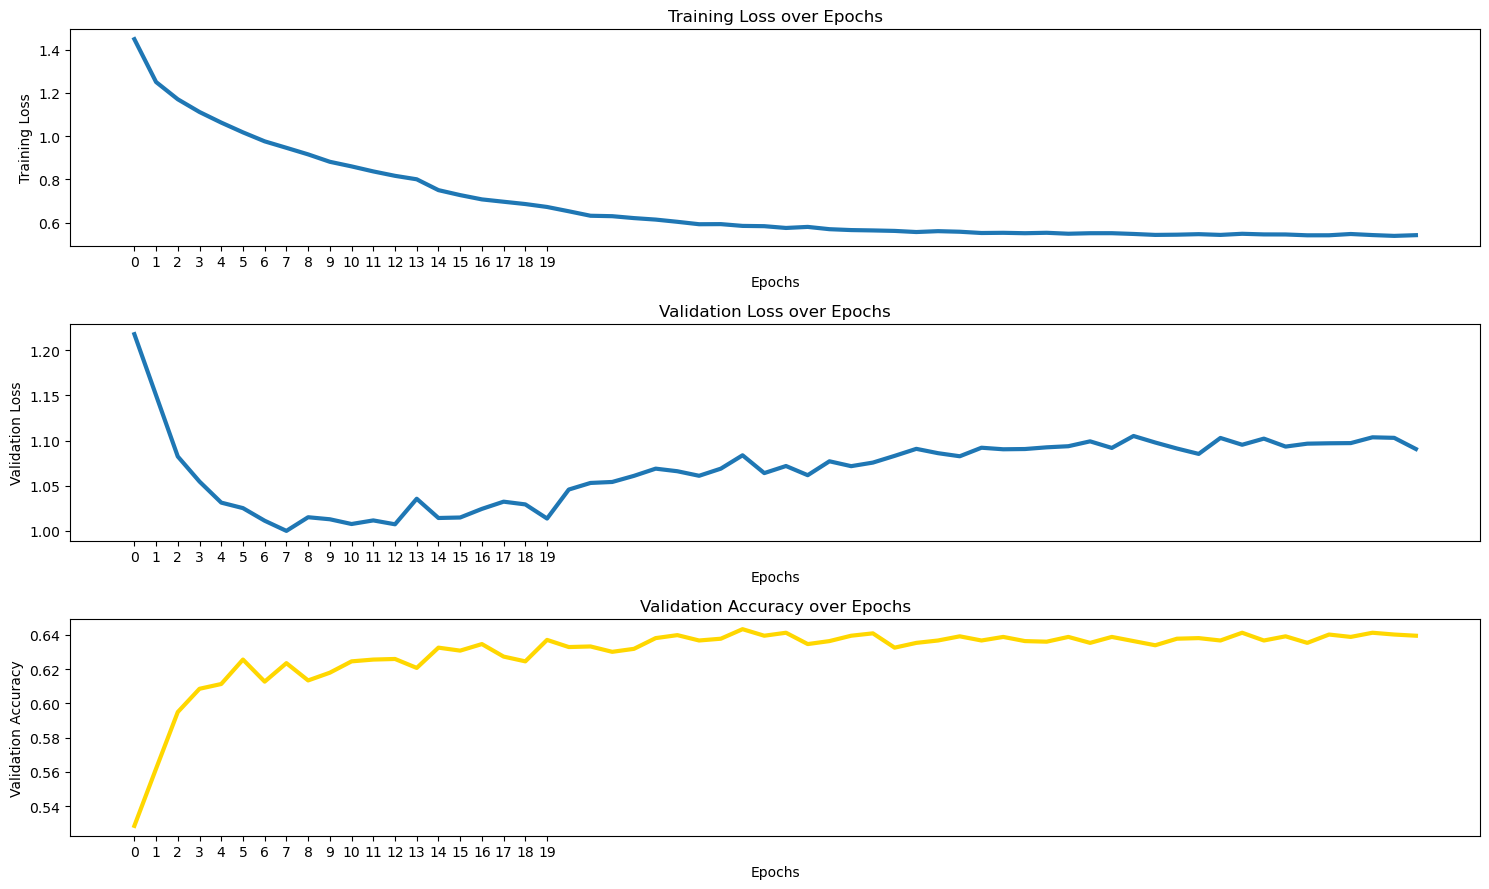

In [302]:
# Visualizing training loss and validation set accuracy
plt.figure(figsize = (15, 9))
xt = np.arange(20)

# Plot for Training Loss
plt.subplot(3, 1, 1)
plt.plot(train_loss_list, linewidth = 3)
plt.title("Training Loss over Epochs")
plt.ylabel("Training Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

plt.subplot(3, 1, 2)
plt.plot(validation_loss_list, linewidth = 3)
plt.title("Validation Loss over Epochs")
plt.ylabel("Validation Loss")
plt.xlabel("Epochs")
plt.xticks(xt)

# Accuracy for validation set
plt.subplot(3, 1, 3)
plt.plot(validation_accuracy_list, linewidth = 3, color = 'gold')
plt.title("Validation Accuracy over Epochs")
plt.ylabel("Validation Accuracy")
plt.xlabel("Epochs")
plt.xticks(xt)
plt.tight_layout() #googled for overlapping labels
plt.show()

In [303]:
print(train_loss_list)
print(validation_loss_list)
print(validation_accuracy_list)

[1.4484257740871087, 1.2501398915845912, 1.170274631194655, 1.1114057419100782, 1.0624123465166004, 1.0172806134903025, 0.9757111555651614, 0.9457595851030143, 0.915385130389187, 0.8811162886973875, 0.859801888576602, 0.8365692221712402, 0.8161245491851594, 0.8001203191169645, 0.7499492130412406, 0.7269501369250448, 0.7071384840520912, 0.6962858174053878, 0.6856430258728772, 0.6721073496821495, 0.65213566612533, 0.6314705386065846, 0.6294227228445165, 0.6205925832776462, 0.6137009765526089, 0.6034496512944484, 0.5922165434796005, 0.5927262078497801, 0.584495622491689, 0.58320419378694, 0.5749767470285988, 0.5798635162067118, 0.569292348614049, 0.5651767354077968, 0.5635337850626777, 0.5613489121475456, 0.5561365818645194, 0.5601753863203267, 0.5575005200163868, 0.5516451180903904, 0.5525590838478076, 0.5506362252744728, 0.5526430787132252, 0.5482499483753653, 0.550640517565488, 0.5507548946714254, 0.5472357647337781, 0.5428328518804751, 0.5438510428825768, 0.5462654152983113, 0.5428314

Test

In [306]:
# Compute the testing accuracy
model.eval() # good practice again
with torch.no_grad():
    # testing model on test samples to get predicted values
    y_pred_test = model(testing_inputs) 
    
    # Use the same technique as above to compute the testing classification accuracy
    predicted_targets = torch.argmax(y_pred_test, dim=1)
    correct = (predicted_targets == testing_targets).type(torch.FloatTensor)
    
    print("Testing Accuracy: " + str(correct.mean().numpy()*100) + '%') # printing the percentage

Testing Accuracy: 64.809135%


In [305]:
tt = testing_targets.cpu().numpy() #these are my true labels
pt = predicted_targets.cpu().numpy() # these are the predicted labels

# List of the different items we classified
c = ["angry", "disgust", "fear", "happy", "neutral", "sad", "surprise"]

print("--- Accuracy By Class ---\n")

# Looping over different classes/targets
for i in range(7):
    # Finding the accuracy:
    idx_k = np.where(tt==i) # finding true labels' indexs
    predicted_k = pt[idx_k] # using idx_k to find the predicted labels
    true_k = tt[idx_k] # getting the true labels
    percent_k = np.mean(predicted_k == true_k) # comparing true vs predicted

    # printing and formatting
    print("Accuracy of", c[i]+":", f"{percent_k*100:.2f}%")
    # ^ I used an f-string cuz it made formatting the percentage nicer

--- Accuracy By Class ---

Accuracy of angry: 53.08%
Accuracy of disgust: 50.46%
Accuracy of fear: 42.29%
Accuracy of happy: 83.65%
Accuracy of neutral: 66.13%
Accuracy of sad: 54.61%
Accuracy of surprise: 81.25%
